# ANÁLISIS DE LA DEUDA EN SALDO E INCUMPLIMIENTO 
**Proyecto:** Simulació Empresarial IT Academy — Bank Marketing  
**Equipo:** Analistas de Finanzas y Riesgo Crediticio  
**Pregunta:** *Los clientes con préstamos e hipotecas tienden a tener un ¿saldo medio más bajo o más riesgo de incumplimiento? Cómo deberíamos ajustar nuestras ofertas y estrategias de gestión de riesgos en función de estos hallazgos?*

---
**Variables:** `balance` (numérica continua — saldo anual promedio en €) · `default` (binaria — crédito en mora: sí/no)  . `loan` (binaria — Prestamos: : sí/no) . housing ((binaria — Hipotecas: : sí/no) **Técnica:** Análisis Bivariado Segmentado 

### 1. IMPORTACIÓN DE LIBRERÍAS

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy.stats import mannwhitneyu, chi2_contingency

### 2. CARGA DE DATOS

In [46]:
df = pd.read_parquet("df_limpiado_260427.parquet")

### 3. SELECCIÓN DE VARIABLES RELEVANTES

In [47]:
df = df[['housing', 'loan', 'balance', 'default']].copy()

In [48]:
variables = pd.DataFrame(columns=['Variable', 'Número de valores unicos', 'Tipo','Valores'])
for i, var in enumerate(df.columns):
    variables.loc[i] = [var, df[var].nunique(), df[var].dtype,df[var].unique().tolist()]

variables

,Variable,Número de valores unicos,Tipo,Valores
0,housing,2,string[python],"[yes, no]"
1,loan,2,string[python],"[no, yes]"
2,balance,3771,int64,"[2343, 45, 1270, 2476, 184, 0, 830, 545, 1, 50..."
3,default,2,string[python],"[no, yes]"


In [49]:
# Valores nulos por variable
nulos = df.isnull().sum()

# Calcular el porcentaje de nulos
nulos_porcentaje = (nulos / len(df)) * 100

null_info = pd.DataFrame({
    'Variable': nulos.index,
    'Nulos': nulos.values,
    'Porcentaje de Nulos': nulos_porcentaje.values
})

null_info

,Variable,Nulos,Porcentaje de Nulos
0,housing,0,0.0
1,loan,0,0.0
2,balance,0,0.0
3,default,0,0.0


### 4. CREACIÓN DE VARIABLES DERIVADAS

In [50]:
# Variable numérica de impago (para calcular tasas)
df['default_num'] = (df['default'] == 'yes').astype(int)

In [51]:
# Variable binaria: ¿tiene alguna deuda activa?
df['tiene_deuda'] = np.where(
    (df['housing'] == 'yes') | (df['loan'] == 'yes'),
    'Con Deuda',
    'Sin Deuda'
)

In [52]:
df.loc[(df['loan'] == 'no') & (df['housing'] == 'no'), 'grupo_deuda'] = 'Sin deuda'
df.loc[(df['loan'] == 'no') & (df['housing'] == 'yes'), 'grupo_deuda'] = 'Solo hipoteca'
df.loc[(df['loan'] == 'yes') & (df['housing'] == 'no'), 'grupo_deuda'] = 'Solo préstamo'
df.loc[(df['loan'] == 'yes') & (df['housing'] == 'yes'), 'grupo_deuda'] = 'Ambas deudas'


In [53]:
# Segmentación de saldo (continuidad con Reto 1)
p33, p66 = df['balance'].quantile([0.33, 0.66])

df['balance_cat'] = pd.cut(
    df['balance'],
    bins=[-np.inf, p33, p66, np.inf],
    labels=['bajo', 'medio', 'alto']
)

### 5. EXPLORACIÓN PARA EL ANÁLISIS

In [54]:
# Diagnóstico Inicial de la cartera
exploracion = {
    'n': len(df),
    'tasa_default_%': round(df['default_num'].mean() * 100, 2),
    'asimetria_balance': round(df['balance'].skew(), 2),
    'kurtozis': round(df['balance'].kurt(), 2),
    'mediana_balance': round(df['balance'].median(), 2),
    'media_balance': round(df['balance'].mean(),2)
}

resultado_tabla = pd.Series(exploracion)
print(resultado_tabla)

n                    10987.00
tasa_default_%           1.47
asimetria_balance        8.22
kurtozis               126.39
mediana_balance        556.00
media_balance         1538.16
dtype: float64


In [55]:
# Conteo de casos por grupo
print("\nDistribución de deuda:")
print(df['tiene_deuda'].value_counts())

print("\nDistribución de impago:")
print(df['default'].value_counts())

print("\nDistribución de prestamo:")
print(df['loan'].value_counts())

print("\nDistribución de hipoteca:")
print(df['housing'].value_counts())

print("\nDistribución de grupo de deuda:")
print(df['grupo_deuda'].value_counts())


Distribución de deuda:
tiene_deuda
Con Deuda    5796
Sin Deuda    5191
Name: count, dtype: int64

Distribución de impago:
default
no     10826
yes      161
Name: count, dtype: Int64

Distribución de prestamo:
loan
no     9556
yes    1431
Name: count, dtype: Int64

Distribución de hipoteca:
housing
no     5804
yes    5183
Name: count, dtype: Int64

Distribución de grupo de deuda:
grupo_deuda
Sin deuda        5191
Solo hipoteca    4365
Ambas deudas      818
Solo préstamo     613
Name: count, dtype: int64


### 6. ANÁLISIS PRINCIPAL: DEUDA vs SALDO + IMPAGO

In [56]:
resumen = (
    df.groupby('tiene_deuda', observed=True)
      .agg(
          clientes=('balance', 'count'),
          saldo_mediano=('balance', 'median'),
          saldo_medio=('balance', 'mean'),
          tasa_impago=('default_num', 'mean')
      )
      .reset_index()
)

resumen['tasa_impago'] = (resumen['tasa_impago'] * 100).round(2)
resumen['saldo_medio'] = resumen['saldo_medio'].round(2)

resumen

,tiene_deuda,clientes,saldo_mediano,saldo_medio,tasa_impago
0,Con Deuda,5796,445.5,1233.82,2.00
1,Sin Deuda,5191,703.0,1877.98,0.87


### 7. ANÁLISIS DESAGREGADO: hipoteca y préstamo

In [57]:
resumen_tipo = pd.DataFrame({
    'grupo': ['Hipoteca', 'Préstamo personal'],
    'clientes': [
        df.loc[df['housing'] == 'yes'].shape[0], # Cuenta filas para hipoteca
        df.loc[df['loan'] == 'yes'].shape[0]     # Cuenta filas para préstamo
    ],
    'saldo_mediano': [
        df.loc[df['housing'] == 'yes', 'balance'].median(),
        df.loc[df['loan'] == 'yes', 'balance'].median()
    ],
    'saldo_saldo_medio': [
        df.loc[df['housing'] == 'yes', 'balance'].mean(),
        df.loc[df['loan'] == 'yes', 'balance'].mean()
    ],
    'tasa_impago': [
        df.loc[df['housing'] == 'yes', 'default_num'].mean() * 100,
        df.loc[df['loan'] == 'yes', 'default_num'].mean() * 100
    ]
}).round(2)

resumen_tipo

,grupo,clientes,saldo_mediano,saldo_saldo_medio,tasa_impago
0,Hipoteca,5183,467.0,1271.81,1.60
1,Préstamo personal,1431,296.0,832.69,3.84


### 8. ANÁLISIS DESAGREGADO: Grupos de deuda

In [58]:
cruce = (
    df.groupby('grupo_deuda', observed=True)
      .agg(
          clientes=('balance', 'count'),
          saldo_mediano=('balance', 'median'),          
          saldo_medio=('balance', 'mean'),
          tasa_impago=('default_num', 'mean')
      )
      .assign(tasa_impago=lambda x: x['tasa_impago'] * 100)
      .round(2)
      .reindex(['Sin deuda', 'Solo hipoteca', 'Solo préstamo', 'Ambas deudas'])
      .reset_index()
)

cruce

,grupo_deuda,clientes,saldo_mediano,saldo_medio,tasa_impago
0,Sin deuda,5191,703.0,1877.98,0.87
1,Solo hipoteca,4365,501.0,1365.32,1.40
2,Solo préstamo,613,290.0,912.61,5.38
3,Ambas deudas,818,300.5,772.79,2.69


### 9. DISTRIBUCIÓN PORCENTUAL POR SEGMENTO DE SALDO (CONEXIÓN CON DESAFIO 1)

- Desafío 1 demostró que el segmento "bajo" tiene 3x más impago que "alto"
- Desafío 2 debe demostrar que la DEUDA es lo que empuja a los clientes hacia el segmento "bajo"

In [59]:
segmentos = (
    pd.crosstab(df['tiene_deuda'], df['balance_cat'], normalize='index')
      .mul(100)
      .round(1)
)

segmentos

balance_cat,bajo,medio,alto
tiene_deuda,,,
Con Deuda,37.4,34.0,28.6
Sin Deuda,28.1,31.9,40.0


In [60]:
segmentos_version2 = (
    pd.crosstab(df['tiene_deuda'], df['balance_cat'], normalize='columns')
      .mul(100)
      .round(1)
)

segmentos_version2

balance_cat,bajo,medio,alto
tiene_deuda,,,
Con Deuda,59.8,54.3,44.4
Sin Deuda,40.2,45.7,55.6


In [61]:
segmentos_grupo_deuda = ( 
    pd.crosstab(df['grupo_deuda'], df['balance_cat'], normalize='columns')
      .mul(100)
      .round(1)
)

segmentos_grupo_deuda

balance_cat,bajo,medio,alto
grupo_deuda,,,
Ambas deudas,10.1,7.5,4.8
Sin deuda,40.2,45.7,55.6
Solo hipoteca,41.8,41.2,36.3
Solo préstamo,7.9,5.6,3.3


### 10. PRUEBAS ESTADÍSTICAS: 

##### Prueba 1: TEST Mann-Whitney U para balance

In [62]:
balance_con_deuda = df.loc[df['tiene_deuda'] == 'Con Deuda', 'balance']
balance_sin_deuda = df.loc[df['tiene_deuda'] == 'Sin Deuda', 'balance']

# Aplicar Mann-Whitney U
statistic, p_valor = mannwhitneyu(balance_con_deuda, balance_sin_deuda, alternative='two-sided')

# Resultado
resultado_mann_whitney = pd.DataFrame({
    'U_statistic': [round(statistic, 2)],
    'p_valor': [p_valor],
    'significativo_5%': ['Sí' if p_valor < 0.05 else 'No'],
    'mediana_con_deuda': [balance_con_deuda.median()],
    'mediana_sin_deuda': [balance_sin_deuda.median()],
    'diferencia_medianas': [balance_con_deuda.median() - balance_sin_deuda.median()],
    'interpretacion': 'diferencia significativa en la distribución de balance'
                      if p_valor < 0.05 else
                      'no se observa diferencia significativa en la distribución de balance'
})

resultado_mann_whitney

,U_statistic,p_valor,significativo_5%,mediana_con_deuda,mediana_sin_deuda,diferencia_medianas,interpretacion
0,12538913.5,1.824155e-51,Sí,445.5,703.0,-257.5,diferencia significativa en la distribución de...


##### Prueba 2: CHI-CUADRADO DE INDEPENDENCIA

El análisis descriptivo muestra ASOCIACIÓN entre deuda e impago. Pero ¿es estadísticamente significativa o podría ser azar muestral?

In [63]:
tabla_chi = pd.crosstab(df['tiene_deuda'], df['default'])
chi2, p_valor, gl, esperadas = chi2_contingency(tabla_chi)

resultado_chi = pd.DataFrame({
    'chi2': [round(chi2, 3)],
    'p_valor': [p_valor],
    'grados_libertad': [gl],
    'frecuencia_esperada_min': [round(esperadas.min(), 2)],
    'interpretacion': 'hay asociación entre deuda e incumplimiento'
                      if p_valor < 0.05 else
                      'no hay evidencia de asociación entre deuda e incumplimiento'
})

resultado_chi

,chi2,p_valor,grados_libertad,frecuencia_esperada_min,interpretacion
0,23.631,0.000001,1,76.07,hay asociación entre deuda e incumplimiento


# Colores corporativos para la presentación

In [64]:
azul_banca = "#002060" 
verde_banca = "#2BA86E"
gris_banca = "#A6A6A6"
gris_banca_oscuro = "#3F3838"


# VISUALIZACIONES PARA LA PRESENTACIÓN

### Visualización 1: Distribuciones de saldo de clientes **Sin deuda** y **Con deuda**

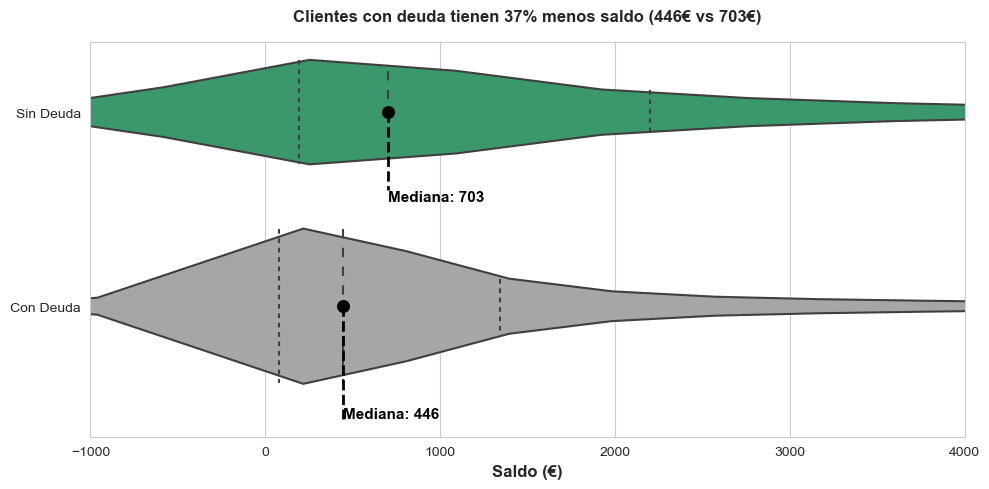

In [65]:
# crear dataframe auxiliar
df_plot = pd.DataFrame({
    'Balance': list(balance_sin_deuda) + list(balance_con_deuda),
    'Grupo': ['Sin Deuda'] * len(balance_sin_deuda) +
             ['Con Deuda'] * len(balance_con_deuda)
})

fig, ax = plt.subplots(figsize=(10,5))

sns.violinplot(
    data=df_plot,
    y='Grupo',
    x='Balance',
    palette=[verde_banca, gris_banca],
    inner='quartile',   
    cut=0,
    ax=ax
)

ax.set_xlim(-1000, 4000)

ymin = ax.get_ylim()[0]

# medianas
med_sin = balance_sin_deuda.median()
med_con = balance_con_deuda.median()

# línea mediana Con Deuda
ax.vlines(
    med_sin,
    ymin=0,          
    ymax=0.4,
    color='black',
    linestyle='--',
    linewidth=2,
    clip_on=False
)

# línea mediana Sin Deuda
ax.vlines(
    med_con,
    ymin=1,
    ymax=ymin+0.08,
    color='black',
    linestyle='--',
    linewidth=2,
    clip_on=False
)


# puntos medianas
ax.scatter(med_sin, 0, color='black', s=70, zorder=5)
ax.scatter(med_con, 1, color='black', s=70, zorder=5)

ax.text(
    med_sin,
    0.4,
    f'Mediana: {med_sin:.0f}',
    ha='left',
    va='top',
    color='black',
    fontweight='bold',
    fontsize=11
)


ax.text(
    med_con,
    ymin + 0.02,
    f'Mediana: {med_con:.0f}',
    ha='left',
    va='top',
    color='black',
    fontweight='bold',
    fontsize=11
)


ax.set_title(
    'Clientes con deuda tienen 37% menos saldo (446€ vs 703€)',
    fontsize=12,
    fontweight="bold",
    pad=15
)

ax.set_xlabel('Saldo (€)', fontsize=12, fontweight="bold")
ax.set_ylabel('')

plt.tight_layout()
plt.savefig('output/viz1_distrib_saldo_sin_con_deuda.png', dpi=300, bbox_inches='tight')
plt.show()

### Visualización 2: Comparacion tasas de impago de clientes **Sin deuda** y **Con deuda**

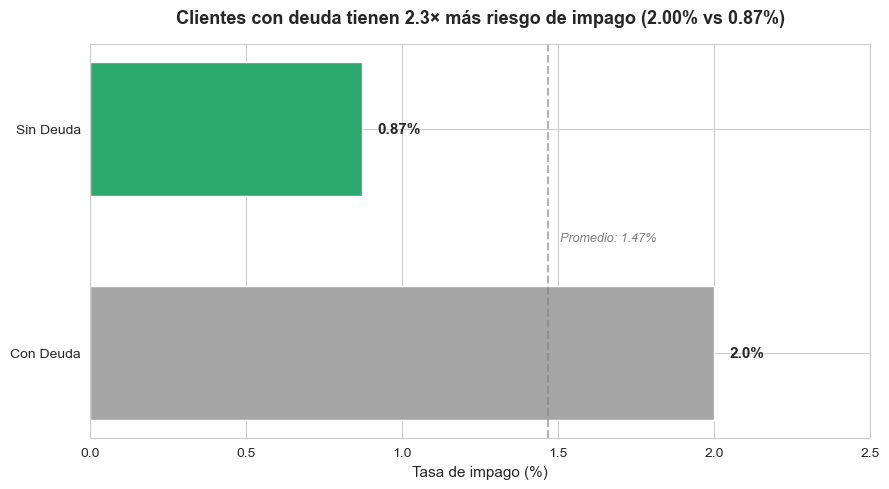

In [66]:
# VISUALIZACIÓN 2: COMPARACIÓN DE IMPAGO - BARRAS HORIZONTALES
# Responde: ¿Los clientes con deuda tienen mayor riesgo de impago?
# Mensaje: "Clientes con deuda tienen 2.3× más impago (2.00% vs 0.87%)"

fig, ax = plt.subplots(figsize=(9, 5))

# Ordenar resumen_deuda para que "Con Deuda" esté arriba
resumen_deuda_sorted = resumen.sort_values('tasa_impago', ascending=False)

colores = [gris_banca, verde_banca]
bars = ax.barh(
    resumen_deuda_sorted['tiene_deuda'], 
    resumen_deuda_sorted['tasa_impago'], 
    color=colores,
    height=0.6
)

# Etiquetas dentro de las barras
for bar, valor in zip(bars, resumen_deuda_sorted['tasa_impago']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, 
            f'{valor}%', ha='left', va='center', fontsize=11, weight='bold')

ax.set_title('Clientes con deuda tienen 2.3× más riesgo de impago (2.00% vs 0.87%)', 
             fontsize=13, weight='bold', pad=15)
ax.set_xlabel('Tasa de impago (%)', fontsize=11)
ax.set_ylabel('')
ax.set_xlim(0, 2.5)

# Línea de referencia (promedio general)
promedio_general = df['default_num'].mean() * 100
ax.axvline(x=promedio_general, color='gray', linestyle='--', linewidth=1.5, alpha=0.6)
ax.text(promedio_general + 0.04, 0.5, f'Promedio: {promedio_general:.2f}%', 
        fontsize=9, style='italic', color='gray')

plt.tight_layout()
plt.savefig('output/viz2_impago_deuda.png', dpi=300, bbox_inches='tight')
plt.show()

### Visualización 3: segmentos de saldo

In [67]:
segmentos

balance_cat,bajo,medio,alto
tiene_deuda,,,
Con Deuda,37.4,34.0,28.6
Sin Deuda,28.1,31.9,40.0


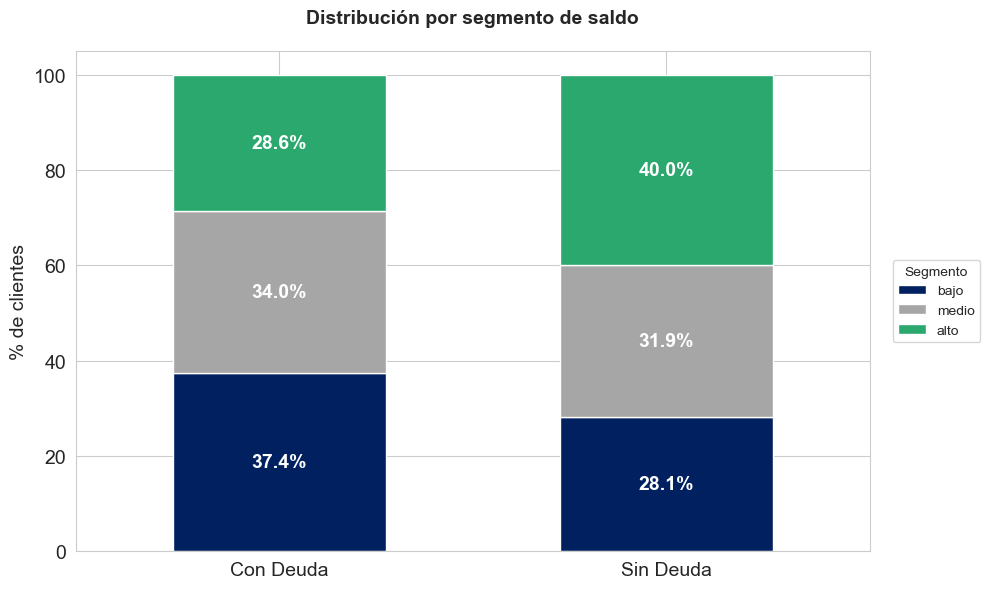

In [68]:
ax = segmentos[['bajo', 'medio', 'alto']].plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=[azul_banca, gris_banca,verde_banca],
    width=0.55,
    fontsize=14
)

# Etiquetas dentro de cada segmento
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='center',   # centro del bloque
        fontsize=14,
        fontweight='bold',
        color='white'
    )

plt.title('Distribución por segmento de saldo',
             fontsize=14, fontweight="bold", pad=20)

ax.legend(
    title='Segmento',
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)) 

plt.ylabel('% de clientes', fontsize=14)
plt.xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('output/viz3_segmentos_saldo_sin_con_deuda.png', dpi=300, bbox_inches='tight')
plt.show()

### Visualización 4: Segmentación cruzada (grafico de burbujas)

In [69]:
cruce

,grupo_deuda,clientes,saldo_mediano,saldo_medio,tasa_impago
0,Sin deuda,5191,703.0,1877.98,0.87
1,Solo hipoteca,4365,501.0,1365.32,1.40
2,Solo préstamo,613,290.0,912.61,5.38
3,Ambas deudas,818,300.5,772.79,2.69


In [70]:
cruce['clientes']

0    5191
1    4365
2     613
3     818
Name: clientes, dtype: int64

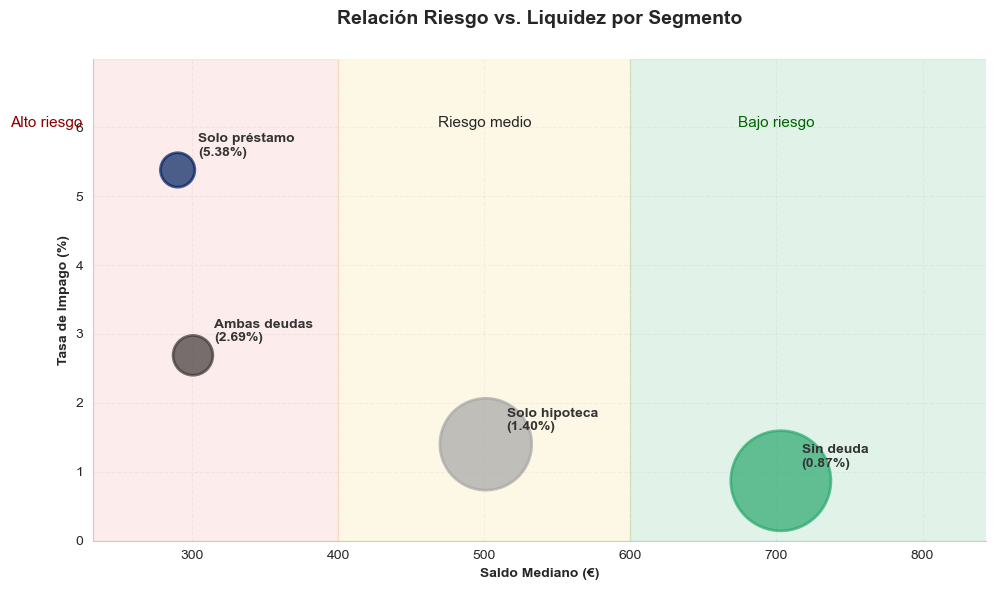

In [ ]:
# 1. Preparación de datos (asegurando el orden de riesgo)
orden_logico = ['Sin deuda', 'Solo hipoteca', 'Solo préstamo', 'Ambas deudas']
cruce_plot = cruce.set_index('grupo_deuda').loc[orden_logico].reset_index()

x = cruce_plot['saldo_mediano']
y = cruce_plot['tasa_impago']
colores = [verde_banca, gris_banca, azul_banca, gris_banca_oscuro]
# El tamaño puede representar el volumen de clientes (opcional)
tamanos = cruce['clientes']

fig, ax = plt.subplots(figsize=(10, 6))

# zonas de fondo
ax.axvspan(0, 400, color='#F08080', alpha=0.15)   # alto riesgo
ax.axvspan(400, 600, color='#F6D55C', alpha=0.15) # medio
ax.axvspan(600, 850, color='#3CB371', alpha=0.15) # bajo riesgo

# 2. Gráfico de Dispersión (Scatter) corregido
# Usamos edgecolors='face' para que el borde coincida con el color del relleno
scatter = ax.scatter(x, y, s=tamanos, c=colores, alpha=0.7, edgecolors='face', linewidth=2)

# 3. Anotaciones dinámicas
for i, txt in enumerate(orden_logico):
    ax.annotate(
        f"{txt}\n({y[i]:.2f}%)", 
        (x[i], y[i]), 
        xytext=(15, 10), 
        textcoords='offset points', 
        fontweight='bold',
        fontsize=10,
        color='#333333'
    )

# 4. Estética y Buenas Prácticas
ax.set_title('Relación Riesgo vs. Liquidez por Segmento', pad=25, fontsize=14, fontweight='bold')
ax.set_xlabel('Saldo Mediano (€)', fontweight='bold')
ax.set_ylabel('Tasa de Impago (%)', fontweight='bold')

# Limpieza visual
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.2)

# Ajuste de márgenes para que no se corten las etiquetas
ax.set_xlim(x.min() * 0.8, x.max() * 1.2)
ax.set_ylim(0, y.max() * 1.3)

plt.tight_layout()
plt.savefig('output/viz4_burbujas_riesgo_saldo', dpi=300, bbox_inches='tight')
plt.show()

# VISUALIZACIONES ALTERNATIVAS

### Visualización 1: saldo e impago

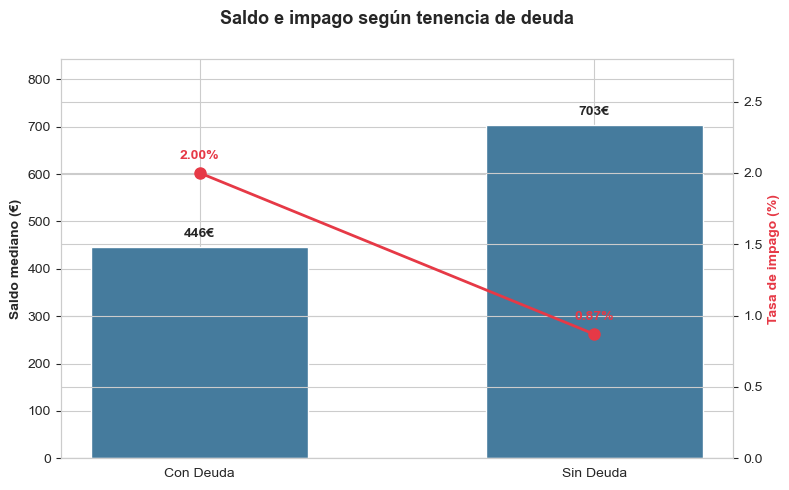

In [72]:
fig, ax1 = plt.subplots(figsize=(8, 5))


bars = ax1.bar(
    resumen['tiene_deuda'],
    resumen['saldo_mediano'],
    color='#457B9D',
    width=0.55
)
ax1.set_ylabel('Saldo mediano (€)', fontweight='bold')
ax1.bar_label(bars, fmt='%.0f€', padding=5, fontweight='bold')


ax1.set_ylim(0, resumen['saldo_mediano'].max() * 1.20)


ax2 = ax1.twinx()
ax2.plot(
    resumen['tiene_deuda'],
    resumen['tasa_impago'],
    color='#E63946',
    marker='o',
    linewidth=2,
    markersize=8
)
ax2.set_ylabel('Tasa de impago (%)', fontweight='bold', color='#E63946')


ax2.set_ylim(0, resumen['tasa_impago'].max() * 1.40)


for x, y in zip(resumen['tiene_deuda'], resumen['tasa_impago']):
    ax2.annotate(f'{y:.2f}%', (x, y), 
                 textcoords='offset points', 
                 xytext=(0, 10), 
                 ha='center', 
                 fontweight='bold',
                 color='#E63946')



plt.title('Saldo e impago según tenencia de deuda', 
          fontsize=13, fontweight="bold", pad=25)

plt.tight_layout()
plt.show()

### Visualización 2: balance por grupo

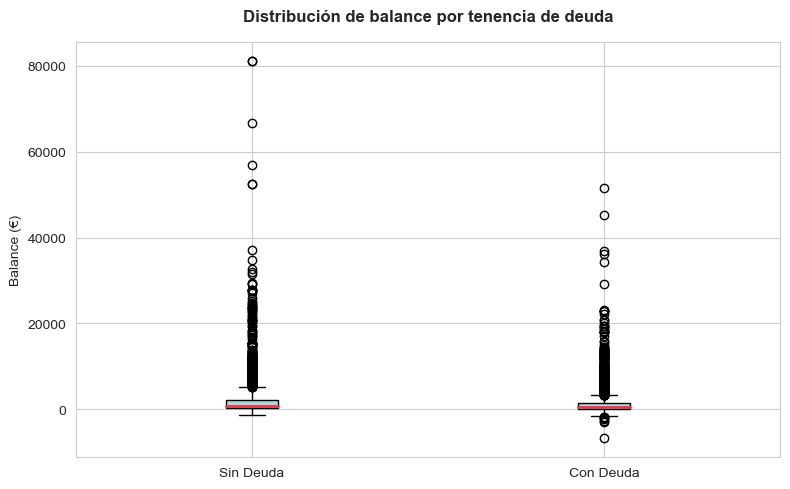

In [73]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(
    [balance_sin_deuda, balance_con_deuda],
    labels=['Sin Deuda', 'Con Deuda'],
    patch_artist=True,
    boxprops=dict(facecolor='#A8DADC'),
    medianprops=dict(color='#E63946', linewidth=2)
)
ax.set_title('Distribución de balance por tenencia de deuda',
             fontsize=12, fontweight="bold", pad=15)
ax.set_ylabel('Balance (€)')
plt.tight_layout()
plt.show()

### Visualización 2.1: balance por grupo de deuda

In [74]:
df['grupo_deuda'].value_counts()

grupo_deuda
Sin deuda        5191
Solo hipoteca    4365
Ambas deudas      818
Solo préstamo     613
Name: count, dtype: int64

In [75]:
balance_sin_deuda = df.loc[df['grupo_deuda'] == 'Sin deuda', 'balance']
balance_solo_hipoteca = df.loc[df['grupo_deuda'] == 'Solo hipoteca', 'balance']
balance_solo_prestamo = df.loc[df['grupo_deuda'] == 'Solo préstamo', 'balance']
balance_ambas_deudas = df.loc[df['grupo_deuda'] == 'Ambas deudas', 'balance']


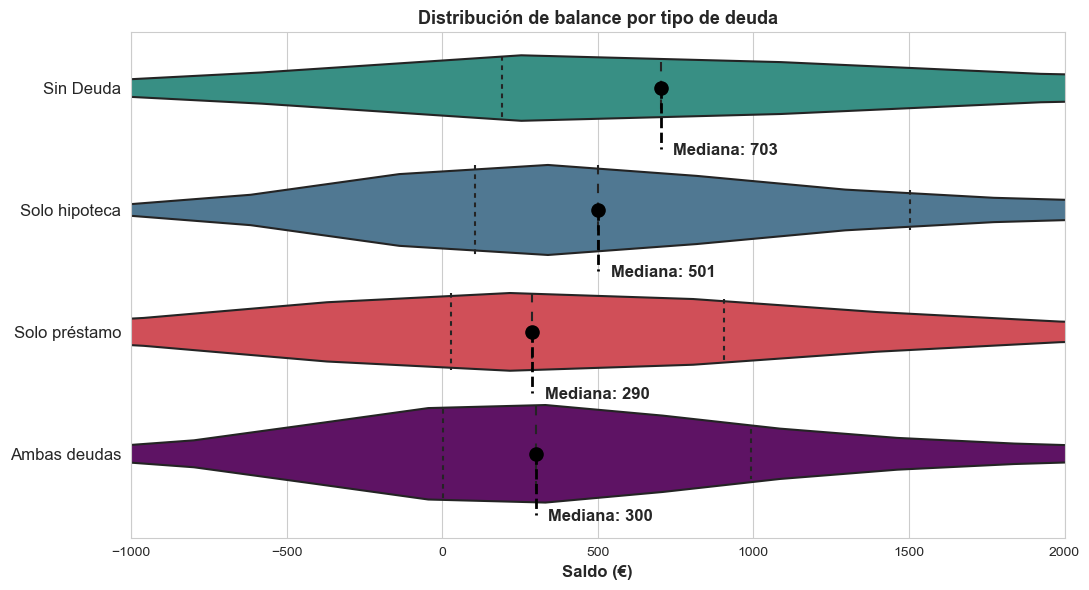

In [76]:
# dataframe auxiliar
df_plot = pd.DataFrame({
    'Balance': list(balance_sin_deuda) +
               list(balance_solo_hipoteca) +
               list(balance_solo_prestamo) +
               list(balance_ambas_deudas),

    'Grupo': (
        ['Sin Deuda'] * len(balance_sin_deuda) +
        ['Solo hipoteca'] * len(balance_solo_hipoteca) +
        ['Solo préstamo'] * len(balance_solo_prestamo) +
        ['Ambas deudas'] * len(balance_ambas_deudas)
    )
})

orden = ['Sin Deuda','Solo hipoteca','Solo préstamo','Ambas deudas']

fig, ax = plt.subplots(figsize=(11,6))

sns.violinplot(
    data=df_plot,
    x='Balance',
    y='Grupo',
    order=orden,
    palette=['#2A9D8F','#457B9D','#E63946','#6A0572'],
    inner='quartile',
    cut=0,
    ax=ax
)

# medianas
medianas = df_plot.groupby('Grupo')['Balance'].median()

# posiciones Y
for i, grupo in enumerate(orden):

    med = medianas[grupo]

    # punto
    ax.scatter(med, i, s=90, color='black', zorder=5)

    # línea punteada abajo
    ax.vlines(
        med,
        ymin=i,
        ymax=i+0.5,
        linestyle='--',
        color='black',
        linewidth=2
    )

    # texto
    ax.text(
        med + 40,
        i + 0.55,
        f'Mediana: {med:.0f}',
        fontsize=12,
        fontweight='bold'
    )

ax.set_xlim(-1000, 2000)

ax.set_title(
    'Distribución de balance por tipo de deuda',
    fontsize=13,
    fontweight='bold'
)

ax.set_xlabel('Saldo (€)', fontsize=12, fontweight='bold')
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=12)

plt.tight_layout()
plt.show()

In [77]:
segmentos_version2

balance_cat,bajo,medio,alto
tiene_deuda,,,
Con Deuda,59.8,54.3,44.4
Sin Deuda,40.2,45.7,55.6


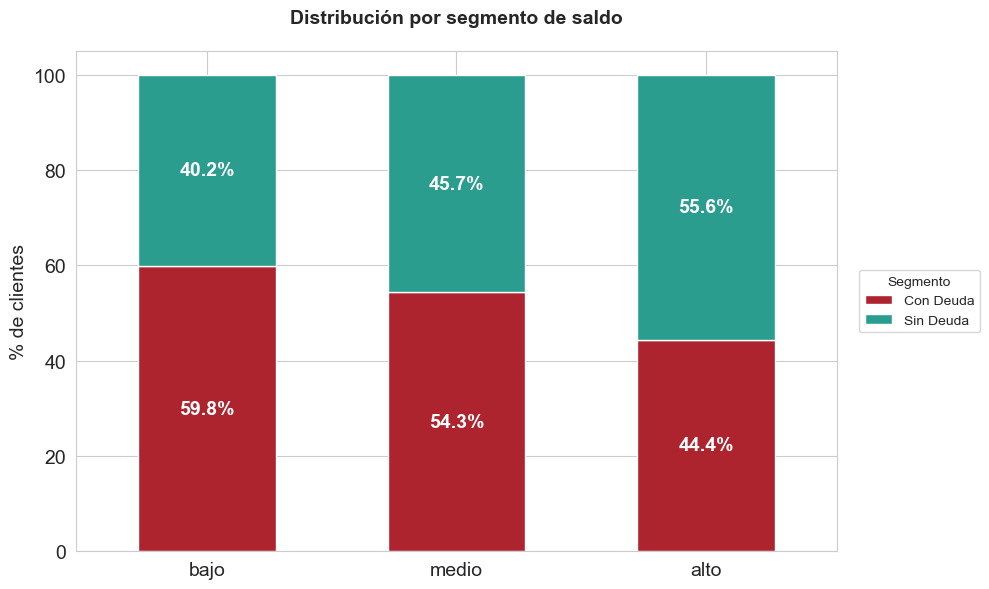

In [78]:
ax = segmentos_version2[['bajo', 'medio', 'alto']].T.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=["#AD242F", '#2A9D8F'],
    width=0.55,
    fontsize=14
)

# Etiquetas dentro de cada segmento
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='center',   # centro del bloque
        fontsize=14,
        fontweight='bold',
        color='white'
    )

plt.title('Distribución por segmento de saldo',
             fontsize=14, fontweight="bold", pad=20)

ax.legend(
    title='Segmento',
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)) 

plt.ylabel('% de clientes', fontsize=14)
plt.xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [79]:
segmentos_grupo_deuda = segmentos_grupo_deuda.sort_values(by='alto')

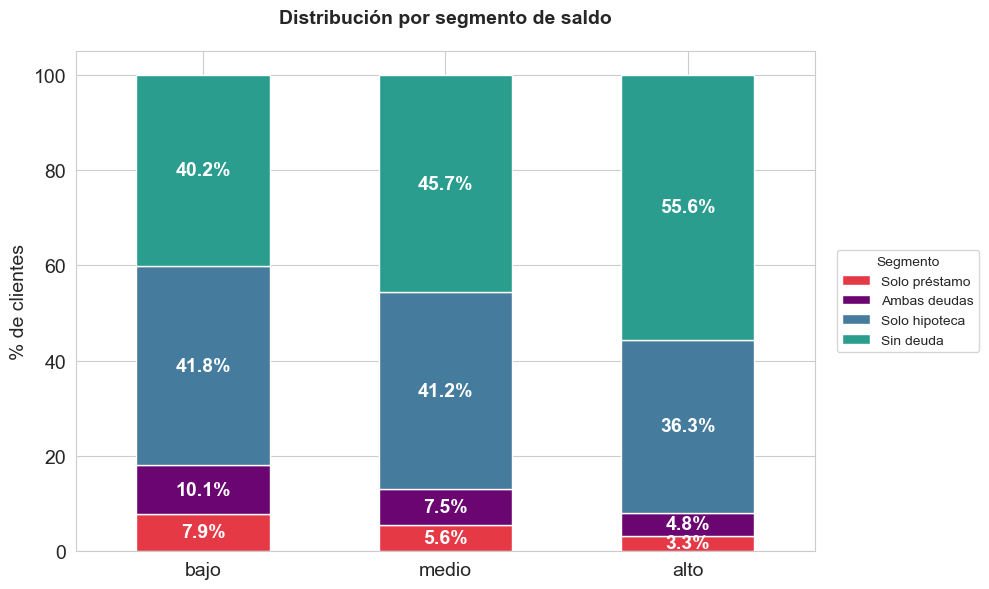

In [80]:
ax = segmentos_grupo_deuda[['bajo', 'medio', 'alto']].T.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=['#E63946', '#6A0572', '#457B9D', '#2A9D8F'],
    width=0.55,
    fontsize=14
)

# Etiquetas dentro de cada segmento
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='center',   # centro del bloque
        fontsize=14,
        fontweight='bold',
        color='white'
    )

plt.title('Distribución por segmento de saldo',
             fontsize=14, fontweight="bold", pad=20)

ax.legend(
    title='Segmento',
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)) 

plt.ylabel('% de clientes', fontsize=14)
plt.xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Visualización 4: tipo de deuda

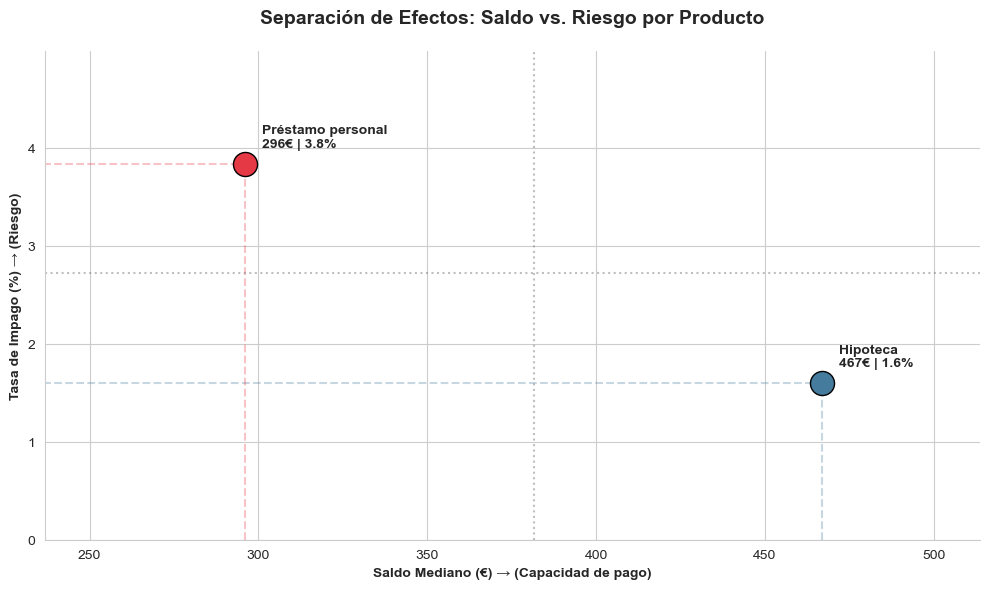

In [81]:
import matplotlib.pyplot as plt

# Configuramos el gráfico
fig, ax = plt.subplots(figsize=(10, 6))

# Colores estratégicos
colores = ['#457B9D', '#E63946'] # Azul para Hipoteca, Rojo para Préstamo
x = resumen_tipo['saldo_mediano']
y = resumen_tipo['tasa_impago']

# Graficamos puntos con líneas de referencia al eje (vlines/hlines)
for i, grupo in enumerate(resumen_tipo['grupo']):
    # Dibujamos el punto
    ax.scatter(x[i], y[i], s=300, color=colores[i], label=grupo, edgecolors='black', zorder=3)
    
    # Líneas de proyección para ver la separación clara de efectos
    ax.vlines(x[i], 0, y[i], linestyle='--', color=colores[i], alpha=0.3, zorder=2)
    ax.hlines(y[i], 0, x[i], linestyle='--', color=colores[i], alpha=0.3, zorder=2)
    
    # Etiqueta de datos enriquecida
    ax.annotate(f"{grupo}\n{x[i]:.0f}€ | {y[i]:.1f}%", 
                (x[i], y[i]), xytext=(12, 12), 
                textcoords='offset points', fontweight='bold')

# Líneas de media para crear cuadrantes (Benchmark)
ax.axhline(y.mean(), color='gray', linestyle=':', alpha=0.5)
ax.axvline(x.mean(), color='gray', linestyle=':', alpha=0.5)

# Personalización estratégica
ax.set_title('Separación de Efectos: Saldo vs. Riesgo por Producto', pad=20, fontsize=14, fontweight='bold')
ax.set_xlabel('Saldo Mediano (€) → (Capacidad de pago)', fontweight='bold')
ax.set_ylabel('Tasa de Impago (%) → (Riesgo)', fontweight='bold')

# Limpieza visual
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(0, y.max() * 1.3)
ax.set_xlim(x.min() * 0.8, x.max() * 1.1)

plt.tight_layout()
plt.show()

In [82]:
# Configuración global de estilo
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']


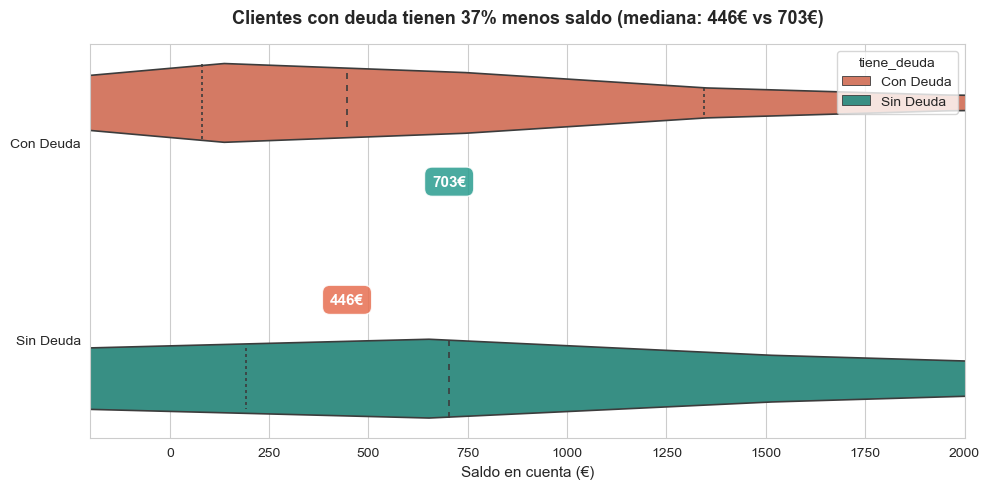

In [83]:
# VISUALIZACIÓN 1: COMPARACIÓN DE SALDO - VIOLIN PLOT

# Responde: ¿Los clientes con deuda tienen saldo más bajo?
# Mensaje: "Clientes con deuda tienen 37% menos liquidez (mediana: 446€ vs 703€)"

fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(
    data=df, 
    x='balance', 
    y='tiene_deuda',
    hue='tiene_deuda',
    palette={'Sin Deuda': '#2A9D8F', 'Con Deuda': '#E76F51'},
    inner='quartile',
    linewidth=1.2,
    legend=False,
    ax=ax
)

ax.set_title('Clientes con deuda tienen 37% menos saldo (mediana: 446€ vs 703€)', 
             fontsize=13, weight='bold', pad=15)
ax.set_xlabel('Saldo en cuenta (€)', fontsize=11)
ax.set_ylabel('')
ax.set_xlim(-200, 2000)

# Etiquetas de mediana dentro del gráfico
ax.text(703, 0.2, '703€', ha='center', va='center', fontsize=11, 
        color='white', weight='bold', 
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#2A9D8F', alpha=0.85))
ax.text(446, 0.8, '446€', ha='center', va='center', fontsize=11, 
        color='white', weight='bold', 
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#E76F51', alpha=0.85))

#plt.figtext(0.12, 0.02, 'Fuente: Base de datos bancaria (n=10,987 clientes) | Abril 2026', 
#            ha='left', fontsize=8, style='italic', color='gray')

plt.tight_layout()
plt.savefig('output/viz1_violin_saldo.png', dpi=300, bbox_inches='tight')
plt.show()

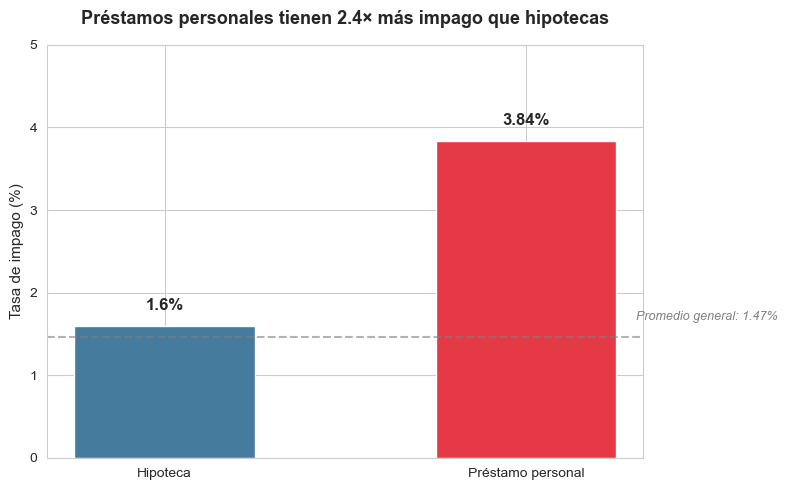

In [84]:
# VISUALIZACIÓN 3: IMPAGO POR TIPO DE DEUDA - BARRAS VERTICALES
# Responde: ¿Qué tipo de deuda genera más riesgo?
# Mensaje: "Préstamos personales tienen 2.4× más impago que hipotecas (3.84% vs 1.60%)"

fig, ax = plt.subplots(figsize=(8, 5))

colores_tipo = ['#457B9D', '#E63946']
bars = ax.bar(
    resumen_tipo['grupo'], 
    resumen_tipo['tasa_impago'], 
    color=colores_tipo,
    width=0.5
)

# Etiquetas sobre las barras
for bar, valor in zip(bars, resumen_tipo['tasa_impago']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15, 
            f'{valor}%', ha='center', va='bottom', fontsize=12, weight='bold')

ax.set_title('Préstamos personales tienen 2.4× más impago que hipotecas', 
             fontsize=13, weight='bold', pad=15)
ax.set_ylabel('Tasa de impago (%)', fontsize=11)
ax.set_xlabel('')
ax.set_ylim(0, 5)

# Línea de referencia (promedio general)
ax.axhline(y=promedio_general, color='gray', linestyle='--', linewidth=1.5, alpha=0.6)
ax.text(1.5, promedio_general + 0.2, f'Promedio general: {promedio_general:.2f}%', 
        fontsize=9, style='italic', color='gray', ha='center')

plt.tight_layout()
plt.savefig('output/viz3_impago_tipo_deuda.png', dpi=300, bbox_inches='tight')
plt.show()

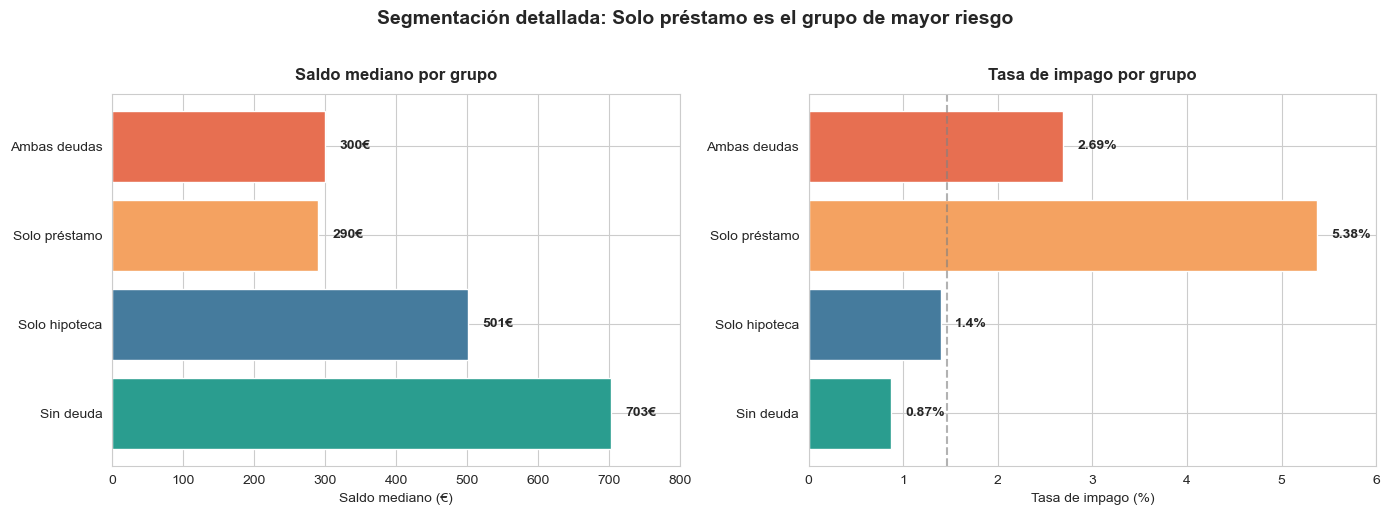

In [85]:
# VISUALIZACIÓN 4: SEGMENTACIÓN DETALLADA - BARRAS AGRUPADAS
# Responde: ¿Cómo se comportan los grupos combinados de deuda?
# Mensaje: "Clientes con solo préstamo tienen 5.38% impago (riesgo crítico)"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: Saldo mediano
colores_grupos = ['#2A9D8F', '#457B9D', '#F4A261', '#E76F51']
bars1 = ax1.barh(
    cruce['grupo_deuda'], 
    cruce['saldo_mediano'], 
    color=colores_grupos
)

for bar, valor in zip(bars1, cruce['saldo_mediano']):
    ax1.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2, 
             f'{valor:.0f}€', ha='left', va='center', fontsize=10, weight='bold')

ax1.set_title('Saldo mediano por grupo', fontsize=12, weight='bold', pad=10)
ax1.set_xlabel('Saldo mediano (€)', fontsize=10)
ax1.set_ylabel('')
ax1.set_xlim(0, 800)

# Panel derecho: Tasa de impago
bars2 = ax2.barh(
    cruce['grupo_deuda'], 
    cruce['tasa_impago'], 
    color=colores_grupos
)

for bar, valor in zip(bars2,cruce['tasa_impago']):
    ax2.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height()/2, 
             f'{valor}%', ha='left', va='center', fontsize=10, weight='bold')

ax2.set_title('Tasa de impago por grupo', fontsize=12, weight='bold', pad=10)
ax2.set_xlabel('Tasa de impago (%)', fontsize=10)
ax2.set_ylabel('')
ax2.set_xlim(0, 6)

# Línea de referencia
ax2.axvline(x=promedio_general, color='gray', linestyle='--', linewidth=1.5, alpha=0.6)

plt.suptitle('Segmentación detallada: Solo préstamo es el grupo de mayor riesgo', 
             fontsize=14, weight='bold', y=1.02)

plt.tight_layout()
plt.savefig('output/viz4_grupos_detallados.png', dpi=300, bbox_inches='tight')
plt.show()

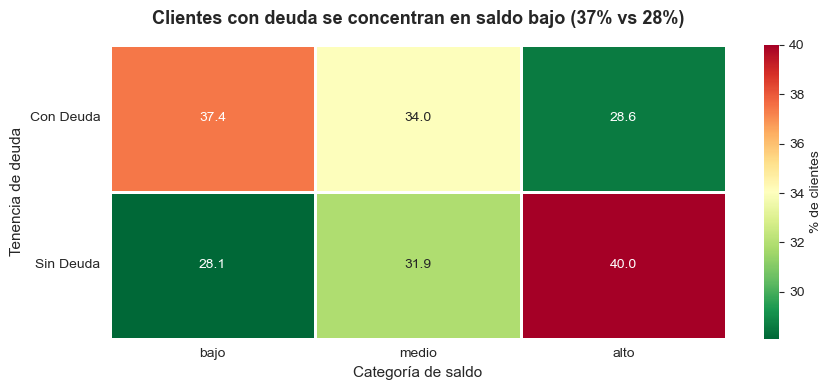

In [86]:
# VISUALIZACIÓN 5: DISTRIBUCIÓN DE SALDO POR CATEGORÍA - HEATMAP

# Responde: ¿Cómo se distribuyen los clientes con deuda en los segmentos de saldo?
# Mensaje: "37% de clientes con deuda están en saldo bajo (vs 28% sin deuda)"

fig, ax = plt.subplots(figsize=(9, 4))

# Crear heatmap usando tabla_cruzada (ya creada en tu código)
sns.heatmap(
    segmentos, 
    annot=True, 
    fmt='.1f', 
    cmap='RdYlGn_r',
    cbar_kws={'label': '% de clientes'},
    linewidths=1,
    linecolor='white',
    ax=ax
)

ax.set_title('Clientes con deuda se concentran en saldo bajo (37% vs 28%)', 
             fontsize=13, weight='bold', pad=15)
ax.set_xlabel('Categoría de saldo', fontsize=11)
ax.set_ylabel('Tenencia de deuda', fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('output/viz5_heatmap_saldo.png', dpi=300, bbox_inches='tight')
plt.show()
